# Figure 1 differentiation compilation

Notebook-first assembly for a data-heavy Figure 1 draft based on `hd_mea_differentiation_simulation.ipynb`. Panel `a` is intentionally reserved for a schematic that can be refined here or replaced in Illustrator later. The remaining panels use cached simulation outputs and the composable plotting helpers.

In [1]:
%matplotlib inline

from dataclasses import asdict, replace
import hashlib
import json
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import LayoutGridPlotter, RestingActivityDataset
from ephax.modeling import (
    HDMEADifferentiationConfig,
    build_kernel_curves,
    build_pruning_milestones,
    make_hd_mea_grid,
    run_apoptosis_simulation,
)
from ephax.plotting import (
    PAPER_COLORS,
    apply_paper_style,
    compose_figure,
    export_figure,
    figure,
    panel,
)
from ephax.plotting.style import LINE_WIDTHS

apply_paper_style()
plt.rcParams["figure.dpi"] = 170

/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configuration and cache

The cache stores the minimal objects needed for layout iteration. Set `FORCE_RERUN = True` after changing simulation parameters.

In [2]:
FORCE_RERUN = True
SHOW_PLACEHOLDERS = True
SAVE_FIGURE = True
CACHE_VERSION = "figure5_aligned_differentiation_v1"

OUTPUT_DIR = repo_root / "outputs" / "figure1_differentiation"
CACHE_PATH = OUTPUT_DIR / "simulation_cache.pkl"
EMPIRICAL_FIGURE5_TARGET_CACHE_PATH = OUTPUT_DIR / "figure5_empirical_target_cache.pkl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE5_TABLE_DIR = repo_root / "outputs" / "figure5_generative_model_grid_search" / "tables"
FIGURE5_GRID_SEARCH_PROFILE_FALLBACK = "screen"
FIGURE5_RANDOM_SEED_FALLBACK = 0
FIGURE5_SUBSAMPLE_SIZE_FALLBACK = 20
FIGURE5_PLATING_LOSS_FRACTION_FALLBACK = 0.70
FIGURE5_TARGET_FRACTION_FALLBACK = 0.40
FIGURE5_MILESTONE_STEP_FRACTION_FALLBACK = 0.20
FIGURE5_NEAR_FIELD_DECAY_UM_FALLBACK = 100.0
FIGURE5_LAMBDA_EPH_UM_FALLBACK = 1_000_000.0
FIGURE5_V_EPH_M_S_FALLBACK = 0.0833
FIGURE5_V_AX_M_S_FALLBACK = 0.60
MODEL_LABELS = {
    "axonal_only": "Axonal only",
    "ephaptic_axonal": "Ephaptic-axonal",
}
MODEL_COLORS = {
    "axonal_only": PAPER_COLORS["axonal_only"],
    "ephaptic_axonal": PAPER_COLORS["ephaptic_axonal"],
    "ephaptic_term": PAPER_COLORS["ephaptic_term"],
}


def _latest_figure5_grid_summary_path():
    paths = sorted(FIGURE5_TABLE_DIR.glob("grid_search_summary_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not paths:
        raise FileNotFoundError(
            "No Figure 5 grid-search summary found. Run figure_5_generative_model_grid_search.ipynb first."
        )
    return paths[0]


def _read_figure5_methods_for_summary(summary_path):
    digest = summary_path.stem.replace("grid_search_summary_", "")
    methods_path = FIGURE5_TABLE_DIR / f"figure5_methods_{digest}.csv"
    if not methods_path.exists():
        return {}, None
    methods = pd.read_csv(methods_path)
    return dict(zip(methods["parameter"].astype(str), methods["value"].astype(str))), methods_path


def _method_float(methods, key, default):
    try:
        return float(methods.get(key, default))
    except (TypeError, ValueError):
        return float(default)


def _method_int(methods, key, default):
    try:
        return int(float(methods.get(key, default)))
    except (TypeError, ValueError):
        return int(default)


def _grid_profile_values(profile):
    if profile == "screen":
        return 110, 60, 35.0
    if profile == "confirm":
        return 220, 120, 17.5
    raise ValueError(f"Unknown Figure 5 grid-search profile: {profile!r}")


FIGURE5_GRID_SUMMARY_PATH = _latest_figure5_grid_summary_path()
FIGURE5_METHOD_VALUES, FIGURE5_METHODS_PATH = _read_figure5_methods_for_summary(FIGURE5_GRID_SUMMARY_PATH)
FIGURE5_GRID_SUMMARY = pd.read_csv(FIGURE5_GRID_SUMMARY_PATH)
if FIGURE5_GRID_SUMMARY.empty:
    raise ValueError(f"Figure 5 grid-search summary is empty: {FIGURE5_GRID_SUMMARY_PATH}")

FIGURE5_GRID_SEARCH_PROFILE = FIGURE5_METHOD_VALUES.get("GRID_SEARCH_PROFILE", FIGURE5_GRID_SEARCH_PROFILE_FALLBACK)
FIGURE5_GRID_COLUMNS, FIGURE5_GRID_ROWS, FIGURE5_PITCH_UM = _grid_profile_values(FIGURE5_GRID_SEARCH_PROFILE)
RANDOM_SEED = _method_int(FIGURE5_METHOD_VALUES, "RANDOM_SEED", FIGURE5_RANDOM_SEED_FALLBACK)
SIMULATION_SUBSAMPLE_SIZE = _method_int(FIGURE5_METHOD_VALUES, "SIMULATION_SUBSAMPLE_SIZE", FIGURE5_SUBSAMPLE_SIZE_FALLBACK)
SIMULATION_PLATING_LOSS_FRACTION = _method_float(FIGURE5_METHOD_VALUES, "SIMULATION_PLATING_LOSS_FRACTION", FIGURE5_PLATING_LOSS_FRACTION_FALLBACK)
SIMULATION_TARGET_FRACTION = _method_float(FIGURE5_METHOD_VALUES, "SIMULATION_TARGET_FRACTION", FIGURE5_TARGET_FRACTION_FALLBACK)
SIMULATION_MILESTONE_STEP_FRACTION = _method_float(FIGURE5_METHOD_VALUES, "SIMULATION_MILESTONE_STEP_FRACTION", FIGURE5_MILESTONE_STEP_FRACTION_FALLBACK)
NEAR_FIELD_DECAY_UM = _method_float(FIGURE5_METHOD_VALUES, "NEAR_FIELD_DECAY_UM", FIGURE5_NEAR_FIELD_DECAY_UM_FALLBACK)
V_EPH_M_S = _method_float(FIGURE5_METHOD_VALUES, "V_EPH_M_S", FIGURE5_V_EPH_M_S_FALLBACK)
V_AX_M_S = _method_float(FIGURE5_METHOD_VALUES, "V_AX_M_S", FIGURE5_V_AX_M_S_FALLBACK)
LAMBDA_EPH_UM = _method_float(FIGURE5_METHOD_VALUES, "LAMBDA_EPH_UM", FIGURE5_LAMBDA_EPH_UM_FALLBACK)


def _best_figure5_rows(summary):
    rows = []
    for model in ["axonal_only", "ephaptic_axonal"]:
        sub = summary.loc[summary["model"].astype(str) == model].copy()
        if sub.empty:
            raise ValueError(f"Figure 5 grid-search summary has no rows for model={model!r}")
        rows.append(sub.loc[sub["ks_statistic_mean"].astype(float).idxmin()])
    return pd.DataFrame(rows).reset_index(drop=True)


FIGURE5_BEST_ROWS = _best_figure5_rows(FIGURE5_GRID_SUMMARY)


def figure5_base_simulation_config(**overrides):
    cfg = HDMEADifferentiationConfig(
        grid_columns=int(FIGURE5_GRID_COLUMNS),
        grid_rows=int(FIGURE5_GRID_ROWS),
        pitch_um=float(FIGURE5_PITCH_UM),
        hz=float(HDMEADifferentiationConfig().hz),
        v_eph_m_s=float(V_EPH_M_S),
        v_ax_m_s=float(V_AX_M_S),
        lambda_eph_um=float(LAMBDA_EPH_UM),
        axonal_decay_um=float(HDMEADifferentiationConfig().axonal_decay_um),
        near_field_decay_um=float(NEAR_FIELD_DECAY_UM),
        near_field_relative_amplitude=float(HDMEADifferentiationConfig().near_field_relative_amplitude),
        subsample_size=int(SIMULATION_SUBSAMPLE_SIZE),
        random_seed=int(RANDOM_SEED),
        plating_loss_fraction=float(SIMULATION_PLATING_LOSS_FRACTION),
        target_fraction=float(SIMULATION_TARGET_FRACTION),
        milestone_step_fraction=float(SIMULATION_MILESTONE_STEP_FRACTION),
    )
    return replace(cfg, **overrides)


sim_config = figure5_base_simulation_config()
PITCH_UM = sim_config.pitch_um
TARGET_COUNT = sim_config.target_count

EMPIRICAL_SELECTED_ELECTRODE_TABLE_PATH = repo_root / "outputs" / "figure4_activity_distance" / "tables" / "selected_electrode_coords.csv.gz"
FIGURE5_DATASET = FIGURE5_METHOD_VALUES.get("DATASET", "stim_removal_null")
FIGURE5_AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
FIGURE5_TARGET_DIV = _method_int(FIGURE5_METHOD_VALUES, "TARGET_DIV", 26)
FIGURE5_EMPIRICAL_TOP_N = _method_int(FIGURE5_METHOD_VALUES, "EMPIRICAL_TOP_N", 100)
PLATING_METHODS_IMAGE_PATH = repo_root / "ephaptic-axonal-plating-methods.png"

print(f"Figure 1 d-f aligned to Figure 5 grid summary: {FIGURE5_GRID_SUMMARY_PATH.name}")
if FIGURE5_METHODS_PATH is not None:
    print(f"Figure 5 method settings: {FIGURE5_METHODS_PATH.name}")
FIGURE5_BEST_ROWS[["model", "near_field_relative_amplitude", "axonal_decay_um", "hz", "ks_statistic_mean"]]


Figure 1 d-f aligned to Figure 5 grid summary: grid_search_summary_1399c4511ec1.csv
Figure 5 method settings: figure5_methods_1399c4511ec1.csv


,model,near_field_relative_amplitude,axonal_decay_um,hz,ks_statistic_mean
0,axonal_only,12.589254,125.892541,NaN,0.224945
1,ephaptic_axonal,7.943282,NaN,34.0,0.143292


In [3]:
def _config_from_figure5_best_row(model):
    row = FIGURE5_BEST_ROWS.loc[FIGURE5_BEST_ROWS["model"].astype(str) == model]
    if row.empty:
        raise ValueError(f"Missing Figure 5 best row for {model}")
    row = row.iloc[0]
    overrides = {
        "near_field_relative_amplitude": float(row["near_field_relative_amplitude"]),
        "random_seed": int(RANDOM_SEED),
    }
    if model == "axonal_only":
        overrides["axonal_decay_um"] = float(row["axonal_decay_um"])
    elif model == "ephaptic_axonal":
        overrides["hz"] = float(row["hz"])
    else:
        raise ValueError(f"Unknown model: {model}")
    return figure5_base_simulation_config(**overrides)


MODEL_CONFIGS = {
    "axonal_only": _config_from_figure5_best_row("axonal_only"),
    "ephaptic_axonal": _config_from_figure5_best_row("ephaptic_axonal"),
}


def _jsonable_config(config):
    return {key: (float(value) if isinstance(value, np.floating) else int(value) if isinstance(value, np.integer) else value) for key, value in asdict(config).items()}


def _simulation_cache_key():
    key_payload = {
        "cache_version": CACHE_VERSION,
        "figure5_grid_summary_path": str(FIGURE5_GRID_SUMMARY_PATH),
        "figure5_grid_summary_mtime_ns": FIGURE5_GRID_SUMMARY_PATH.stat().st_mtime_ns,
        "figure5_methods_path": str(FIGURE5_METHODS_PATH) if FIGURE5_METHODS_PATH is not None else None,
        "best_rows": FIGURE5_BEST_ROWS.to_dict(orient="records"),
        "model_configs": {model: _jsonable_config(cfg) for model, cfg in MODEL_CONFIGS.items()},
    }
    encoded = json.dumps(key_payload, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()[:16]


SIMULATION_CACHE_KEY = _simulation_cache_key()


def _cache_is_current(payload):
    return isinstance(payload, dict) and payload.get("cache_version") == CACHE_VERSION and payload.get("cache_key") == SIMULATION_CACHE_KEY


def build_figure5_aligned_differentiation_payload(show_progress=True):
    grid = make_hd_mea_grid(sim_config)
    milestones = build_pruning_milestones(sim_config)
    simulation_results = {}
    history_parts = []
    for model, include_correlation in [("axonal_only", False), ("ephaptic_axonal", True)]:
        result = run_apoptosis_simulation(
            grid,
            MODEL_CONFIGS[model],
            MODEL_LABELS[model],
            include_correlation=include_correlation,
            random_seed=int(RANDOM_SEED),
            milestones=milestones,
            show_progress=show_progress,
        )
        simulation_results[model] = result
        history = result["history"].copy()
        history["model"] = model
        history["model_label"] = MODEL_LABELS[model]
        history_parts.append(history)
    history_df = pd.concat(history_parts, ignore_index=True) if history_parts else pd.DataFrame()
    kernels = {
        "axonal_only": build_kernel_curves(grid, MODEL_CONFIGS["axonal_only"]),
        "ephaptic_axonal": build_kernel_curves(grid, MODEL_CONFIGS["ephaptic_axonal"]),
        "model_configs": MODEL_CONFIGS,
    }
    parameters = {
        **_jsonable_config(sim_config),
        "initial_count": int(sim_config.initial_count),
        "plated_count": int(sim_config.plated_count),
        "target_count": int(sim_config.target_count),
        "figure5_grid_summary_path": str(FIGURE5_GRID_SUMMARY_PATH),
        "figure5_methods_path": str(FIGURE5_METHODS_PATH) if FIGURE5_METHODS_PATH is not None else "",
        "figure5_best_rows": FIGURE5_BEST_ROWS.to_dict(orient="records"),
        "model_configs": {model: _jsonable_config(cfg) for model, cfg in MODEL_CONFIGS.items()},
    }
    return {
        "cache_version": CACHE_VERSION,
        "cache_key": SIMULATION_CACHE_KEY,
        "grid": grid,
        "kernels": kernels,
        "milestones": milestones,
        "ordered_labels": list(milestones.keys()),
        "simulation_results": simulation_results,
        "history_df": history_df,
        "parameters": parameters,
    }


if CACHE_PATH.exists() and not FORCE_RERUN:
    with CACHE_PATH.open("rb") as f:
        payload = pickle.load(f)
    if not _cache_is_current(payload):
        payload = build_figure5_aligned_differentiation_payload(show_progress=True)
        with CACHE_PATH.open("wb") as f:
            pickle.dump(payload, f)
else:
    payload = build_figure5_aligned_differentiation_payload(show_progress=True)
    with CACHE_PATH.open("wb") as f:
        pickle.dump(payload, f)

grid = payload["grid"]
kernels = payload["kernels"]
milestones = payload["milestones"]
ordered_labels = payload["ordered_labels"]
simulation_results = payload["simulation_results"]
history_df = payload["history_df"]
params = payload["parameters"]

print(f"Loaded Figure 1 simulation cache: {CACHE_PATH}")
print(f"Cache key: {payload['cache_key']}")
print(f"Initial: {params['initial_count']:,}; plated: {params['plated_count']:,}; final target: {params['target_count']:,}")
for model, cfg in MODEL_CONFIGS.items():
    print(
        f"{model}: near={cfg.near_field_relative_amplitude:.3g}, "
        f"decay={cfg.axonal_decay_um:.3g} um, hz={cfg.hz:.3g}, target={cfg.target_fraction:.2f}"
    )


Axonal only apoptosis:   0%|          | 0/1188 [00:00<?, ?neurons/s]

Ephaptic-axonal apoptosis:   0%|          | 0/1188 [00:00<?, ?neurons/s]

Loaded Figure 1 simulation cache: /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/simulation_cache.pkl
Cache key: 3f2ec8288b6e6332
Initial: 6,600; plated: 1,980; final target: 792
axonal_only: near=12.6, decay=126 um, hz=45, target=0.40
ephaptic_axonal: near=7.94, decay=100 um, hz=34, target=0.40


In [4]:
def _figure5_empirical_target_cache_is_current(payload):
    return (
        isinstance(payload, dict)
        and payload.get("cache_version") == CACHE_VERSION
        and payload.get("selected_electrode_table_path") == str(EMPIRICAL_SELECTED_ELECTRODE_TABLE_PATH)
        and payload.get("figure5_grid_summary_path") == str(FIGURE5_GRID_SUMMARY_PATH)
        and payload.get("dataset") == FIGURE5_DATASET
        and payload.get("wells") == FIGURE5_AGGREGATE_WELLS
        and payload.get("target_div") == FIGURE5_TARGET_DIV
        and payload.get("empirical_top_n") == FIGURE5_EMPIRICAL_TOP_N
    )


def _load_figure5_empirical_target():
    if not EMPIRICAL_SELECTED_ELECTRODE_TABLE_PATH.exists():
        raise FileNotFoundError(
            "Missing selected-electrode coordinate table from Figure 4. "
            "Run the Figure 4 selected-electrode table build once, or provide the same table used by Figure 5."
        )
    df = pd.read_csv(EMPIRICAL_SELECTED_ELECTRODE_TABLE_PATH)
    required = {"dataset", "well", "div", "recording_id", "electrode", "selected_rank", "x_um", "y_um"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Selected-electrode table is missing columns: {sorted(missing)}")

    target = df.loc[df["dataset"].astype(str) == str(FIGURE5_DATASET)].copy()
    target = target.loc[target["well"].astype(int).isin([int(w) for w in FIGURE5_AGGREGATE_WELLS])].copy()
    if target.empty:
        raise ValueError(
            f"No selected-electrode rows match dataset={FIGURE5_DATASET!r} and wells={FIGURE5_AGGREGATE_WELLS}."
        )

    available_divs = sorted(target["div"].astype(int).unique().tolist())
    if int(FIGURE5_TARGET_DIV) not in available_divs:
        resolved_div = max(available_divs)
        print(f"Figure 5 target DIV {FIGURE5_TARGET_DIV} not present; using latest available DIV {resolved_div}.")
    else:
        resolved_div = int(FIGURE5_TARGET_DIV)

    target = target.loc[target["div"].astype(int) == resolved_div].copy()
    target["selected_rank"] = pd.to_numeric(target["selected_rank"], errors="coerce")
    target = target.loc[target["selected_rank"] <= int(FIGURE5_EMPIRICAL_TOP_N)].copy()
    if target.empty:
        raise ValueError("No empirical selected electrodes remain after Figure 5 target-DIV/top-N filtering.")

    target = target.sort_values(["well", "recording_id", "selected_rank", "electrode"]).reset_index(drop=True)
    target["resolved_target_div"] = resolved_div
    return target


if EMPIRICAL_FIGURE5_TARGET_CACHE_PATH.exists() and not FORCE_RERUN:
    with EMPIRICAL_FIGURE5_TARGET_CACHE_PATH.open("rb") as f:
        empirical_payload = pickle.load(f)
    if not _figure5_empirical_target_cache_is_current(empirical_payload):
        empirical_payload = None
else:
    empirical_payload = None

if empirical_payload is None:
    empirical_figure5_target = _load_figure5_empirical_target()
    empirical_payload = {
        "cache_version": CACHE_VERSION,
        "selected_electrode_table_path": str(EMPIRICAL_SELECTED_ELECTRODE_TABLE_PATH),
        "figure5_grid_summary_path": str(FIGURE5_GRID_SUMMARY_PATH),
        "dataset": FIGURE5_DATASET,
        "wells": FIGURE5_AGGREGATE_WELLS,
        "target_div": FIGURE5_TARGET_DIV,
        "resolved_target_div": int(empirical_figure5_target["resolved_target_div"].iloc[0]),
        "empirical_top_n": FIGURE5_EMPIRICAL_TOP_N,
        "empirical_figure5_target": empirical_figure5_target,
    }
    with EMPIRICAL_FIGURE5_TARGET_CACHE_PATH.open("wb") as f:
        pickle.dump(empirical_payload, f)

empirical_figure5_target = empirical_payload["empirical_figure5_target"]
resolved_empirical_target_div = int(empirical_payload["resolved_target_div"])
print(
    f"Loaded Figure 5 empirical target for Figure 1f: DIV {resolved_empirical_target_div}, "
    f"top {FIGURE5_EMPIRICAL_TOP_N} active electrodes per recording, "
    f"{empirical_figure5_target['recording_id'].nunique()} recordings, "
    f"{len(empirical_figure5_target):,} selected electrode rows: {EMPIRICAL_FIGURE5_TARGET_CACHE_PATH}"
)


Loaded Figure 5 empirical target for Figure 1f: DIV 21, top 100 active electrodes per recording, 6 recordings, 600 selected electrode rows: /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure5_empirical_target_cache.pkl


## Notebook-local draw functions

These functions are intentionally kept here until the figure stabilizes. They follow the same draw-into-existing-axes convention as package plotting functions.

In [5]:
def _clean_axes(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def draw_figure1_placeholder(_data, ax, *, show_placeholder=True, compact=True, **_opts):
    ax.set_axis_off()
    if show_placeholder:
        ax.text(0.02, 0.80, "schematic placeholder", transform=ax.transAxes, color="0.45")
        ax.text(0.02, 0.55, "Differentiation logic / RQ diagram", transform=ax.transAxes, fontsize=7)
        ax.annotate(
            "",
            xy=(0.72, 0.48),
            xytext=(0.25, 0.48),
            xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "lw": 0.9, "color": "0.25"},
        )
        ax.text(0.47, 0.57, "differentiation", transform=ax.transAxes, ha="center", fontsize=7)
        ax.add_patch(plt.Rectangle((0.01, 0.10), 0.98, 0.78, fill=False, edgecolor="0.85", linewidth=0.6, transform=ax.transAxes))
    return {"axes": ax}


def _draw_schematic_node(ax, xy, *, radius=0.012, edgecolor="0.25", facecolor="white", lw=0.7, alpha=1.0):
    # Scatter marker sizes are in points, so nodes remain circular even when the axes are wide.
    size_pt2 = (radius * 900.0) ** 2
    return ax.scatter([xy[0]], [xy[1]], s=size_pt2, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, alpha=alpha, zorder=3)


def _draw_schematic_edges(ax, positions, pairs, *, color="0.35", lw=0.45, alpha=0.6, ls="-"):
    for i, j in pairs:
        x0, y0 = positions[i]
        x1, y1 = positions[j]
        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha, ls=ls, solid_capstyle="round", zorder=1)


def _nearest_schematic_pairs(positions, k=2):
    coords = np.asarray(positions, dtype=float)
    pairs = set()
    for i in range(len(coords)):
        d = np.sqrt(np.sum((coords - coords[i]) ** 2, axis=1))
        nearest = np.argsort(d)[1 : k + 1]
        for j in nearest:
            pairs.add(tuple(sorted((i, int(j)))))
    return sorted(pairs)


def _schematic_cluster(center, n_nodes, *, rng, rx=0.085, ry=0.16):
    theta = rng.uniform(0, 2 * np.pi, n_nodes)
    radii = np.sqrt(rng.uniform(0.04, 1.0, n_nodes))
    return np.column_stack([center[0] + rx * radii * np.cos(theta), center[1] + ry * radii * np.sin(theta)])


def draw_network_differentiation_schematic(_data, ax, *, compact=True, seed=8, **_opts):
    """Editable schematic for panel a: plated network to sparse modular differentiation."""
    rng = np.random.default_rng(seed)
    ax.set_axis_off()
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

    undiff_color = "#ffb6ae"
    module_a = "#ffc061"
    module_b = "#ff5757"
    bridge_color = "0.35"

    # Undifferentiated plated network: denser, broadly distributed cells with weak local links.
    left_origin = np.array([0.06, 0.16])
    left_size = np.array([0.35, 0.62])
    left_positions = left_origin + rng.random((100, 2)) * left_size
    left_pairs = _nearest_schematic_pairs(left_positions, k=2)
    _draw_schematic_edges(ax, left_positions, left_pairs, color=undiff_color, lw=0.35, alpha=0.28)
    for xy in left_positions:
        _draw_schematic_node(ax, xy, radius=0.0078, edgecolor=undiff_color, facecolor="white", lw=0.55)

    # Differentiated network: two dense modules separated by sparse long-range bridges.
    module_specs = [
        (np.array([0.66, 0.57]), module_a, 18),
        (np.array([0.84, 0.57]), module_b, 18),
    ]
    module_positions = []
    module_ranges = []
    cursor = 0
    for center, color, n_nodes in module_specs:
        xy = _schematic_cluster(center, n_nodes, rng=rng, rx=0.070, ry=0.18)
        module_positions.extend(xy)
        module_ranges.append((cursor, cursor + n_nodes, color, center))
        cursor += n_nodes

    module_positions = np.asarray(module_positions)
    for start, stop, color, center in module_ranges:
        local = module_positions[start:stop]
        local_pairs = [(i + start, j + start) for i, j in _nearest_schematic_pairs(local, k=3)]
        _draw_schematic_edges(ax, module_positions, local_pairs, color=color, lw=0.45, alpha=0.45)
        halo = plt.Circle(center, 0.125, facecolor="none", edgecolor=color, linewidth=0.6, linestyle="--", alpha=0.55, transform=ax.transAxes)
        ax.add_patch(halo)
        for xy in local:
            _draw_schematic_node(ax, xy, radius=0.0078, edgecolor=color, facecolor="white", lw=0.55)

    sparse_bridges = [
        (module_ranges[0][0] + 3, module_ranges[1][0] + 4),
        (module_ranges[0][0] + 9, module_ranges[1][0] + 12),
    ]
    _draw_schematic_edges(ax, module_positions, sparse_bridges, color=bridge_color, lw=0.45, alpha=0.72, ls="--")

    ax.annotate(
        "",
        xy=(0.54, 0.50),
        xytext=(0.44, 0.50),
        xycoords="axes fraction",
        arrowprops={"arrowstyle": "->", "lw": 0.9, "color": "0.2"},
    )
    ax.text(0.235, 0.82, "undifferentiated network", transform=ax.transAxes, ha="center", fontsize=6)
    ax.text(0.75, 0.82, "differentiated network", transform=ax.transAxes, ha="center", fontsize=6)
    ax.text(0.75, 0.14, "Hypothesis:\nEphaptic-axonal interactions\npredict inter-patch distance", transform=ax.transAxes, ha="center", fontsize=6, color="0.35")
    return {"axes": ax}


def draw_plating_methods_image(image_path, ax, *, compact=True, **_opts):
    image = plt.imread(image_path)
    ax.imshow(image, aspect="equal")
    ax.set_axis_off()
    ax.set_anchor("C")
    return {"axes": ax, "image": image}


def draw_kernel_origin_schematic(data, ax, *, compact=True, **_opts):
    """Illustrate how axonal transmission and an extracellular wave combine."""
    ax.set_axis_off()
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

    axonal_color = MODEL_COLORS["axonal_only"]
    ephaptic_color = MODEL_COLORS["ephaptic_axonal"]
    source_xy = (0.14, 0.66)
    target_xy = (0.86, 0.66)

    for xy in [source_xy, target_xy]:
        ax.add_patch(plt.Circle(xy, 0.065, facecolor="white", edgecolor="0.25", lw=0.8))
    ax.text(source_xy[0], source_xy[1], "1", ha="center", va="center", fontsize=6, color="0.25")
    ax.text(target_xy[0], target_xy[1], "2", ha="center", va="center", fontsize=6, color="0.25")

    ax.annotate("", xy=(0.79, 0.66), xytext=(0.21, 0.66), arrowprops={"arrowstyle": "->", "lw": 1.25, "color": axonal_color})
    ax.text(0.50, 0.75, "axonal wave\n(supra-threshold)", ha="center", fontsize=6, color=axonal_color)

    wave_x = np.linspace(0.22, 0.80, 160)
    wave_y = 0.43 + 0.055 * np.sin(5.0 * np.pi * (wave_x - wave_x.min()) / np.ptp(wave_x))
    ax.plot(wave_x, wave_y, color=ephaptic_color, lw=1.25)
    ax.text(0.50, 0.5, "ephaptic wave\n(sub-threshold)", ha="center", fontsize=6, color=ephaptic_color)

    ax.annotate("", xy=(0.79, 0.25), xytext=(0.21, 0.25), arrowprops={"arrowstyle": "<->", "lw": 0.7, "color": "0.35"})
    ax.text(0.50, 0.185, "distance r", ha="center", fontsize=6, color="0.35")
    return {"axes": ax}


def draw_kernel_comparison(data, axes, *, compact=True, show_legend=False, **_opts):
    ax_left, ax_right = axes
    axonal_data = data.get("axonal_only", data)
    ephaptic_data = data.get("ephaptic_axonal", data)
    axonal_cfg = data.get("model_configs", {}).get("axonal_only", sim_config)
    ephaptic_cfg = data.get("model_configs", {}).get("ephaptic_axonal", sim_config)
    r_um = axonal_data["r_um"]
    xmax = min(float(r_um.max()), 3600.0)

    ax_left.plot(r_um, axonal_data["axonal"], color=MODEL_COLORS["axonal_only"], lw=LINE_WIDTHS["emphasis"], label="near-field + axonal")
    ax_left.plot(r_um, axonal_data["near_field"], color=MODEL_COLORS["axonal_only"], lw=LINE_WIDTHS["thin"], ls=":", alpha=0.75, label="near-field")
    ax_left.plot(r_um, axonal_data["axonal_component"], color=MODEL_COLORS["axonal_only"], lw=LINE_WIDTHS["thin"], ls="--", alpha=0.75, label="axonal")
    ax_left.axhline(0.0, color="0.35", lw=LINE_WIDTHS["thin"])
    ax_left.set_title(f"axonal only", color=MODEL_COLORS["axonal_only"])
    ax_left.set_ylabel("Interaction kernel (a.u.)")

    ax_right.plot(r_um, ephaptic_data["ephaptic_axonal"], color=MODEL_COLORS["ephaptic_axonal"], lw=LINE_WIDTHS["emphasis"], label="near-field + ephaptic")
    ax_right.plot(r_um, ephaptic_data["near_field"], color=MODEL_COLORS["ephaptic_axonal"], lw=LINE_WIDTHS["thin"], ls=":", alpha=0.75, label="near-field")
    ax_right.plot(r_um, ephaptic_data["ephaptic"], color=MODEL_COLORS["ephaptic_axonal"], lw=LINE_WIDTHS["thin"], ls="--", alpha=0.75, label="ephaptic")
    ax_right.axvline(ephaptic_data["wavelength_um"], color="0.35", lw=LINE_WIDTHS["thin"], ls="--")
    ax_right.axhline(0.0, color="0.35", lw=LINE_WIDTHS["thin"])
    ax_right.text(
        min(0.96, ephaptic_data["wavelength_um"] / max(xmax, 1.0)),
        0.88,
        f"λ({ephaptic_cfg.hz:.1f} Hz) = {int(ephaptic_data['wavelength_um'])} μm",
        transform=ax_right.transAxes,
        ha="right",
        fontsize=6,
        color="0.35",
    )
    ax_right.set_title("ephaptic-axonal", color=MODEL_COLORS["ephaptic_axonal"])
    if show_legend:
        ax_right.legend(loc="upper right", frameon=False)

    for ax in [ax_left, ax_right]:
        ax.set_xlim(0.0, xmax)
        ax.set_xlabel("Distance (μm)")
        _clean_axes(ax)
    return {"axes": axes}




def draw_node_map(ax, nodes_df, grid, *, title, color, background=None, point_size=1):
    ax.set_facecolor("black")
    if background is not None:
        ax.scatter(background["x_um"], background["y_um"], s=0.05, color="0.20", linewidths=0, rasterized=True)
    ax.scatter(nodes_df["x_um"], nodes_df["y_um"], s=point_size, color=color, linewidths=0, rasterized=True)
    ax.set_aspect("equal")
    ax.set_anchor("N")
    ax.set_xlim(-PITCH_UM, grid["x_um"].max() + PITCH_UM)
    ax.set_ylim(-PITCH_UM, grid["y_um"].max() + PITCH_UM)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_color("0.15")
        spine.set_linewidth(0.5)


def draw_model_outcome_maps(data, axes, *, compact=True, **_opts):
    ax_axonal, ax_ephaptic, *extra_axes = axes
    background = data["simulation_results"]["axonal_only"]["plated_initial"]
    draw_node_map(
        ax_axonal,
        data["simulation_results"]["axonal_only"]["final_active"],
        data["grid"],
        title="axonal only",
        color=MODEL_COLORS["axonal_only"],
        background=background,
    )
    draw_node_map(
        ax_ephaptic,
        data["simulation_results"]["ephaptic_axonal"]["final_active"],
        data["grid"],
        title="ephaptic-axonal",
        color=MODEL_COLORS["ephaptic_axonal"],
        background=background,
    )
    rendered = {"axes": axes}
    if extra_axes and data.get("empirical_figure5_target") is not None:
        target = data["empirical_figure5_target"]
        target_div = int(target["resolved_target_div"].iloc[0]) if "resolved_target_div" in target else FIGURE5_TARGET_DIV
        draw_node_map(
            extra_axes[0],
            target,
            data["grid"],
            title=f"empirical target\nDIV {target_div}, top {FIGURE5_EMPIRICAL_TOP_N}",
            color=PAPER_COLORS["highlight"],
            background=None,
        )
        rendered["empirical_figure5_target"] = extra_axes[0]
    for ax in extra_axes[1:]:
        ax.set_axis_off()
    return rendered


def draw_milestone_strip(data, axes, *, compact=True, **_opts):
    preferred = ["80%", "60%", "40%", "20%", "90%", "70%", "50%"]
    labels = [label for label in preferred if label in data["milestones"]][: len(axes)]
    if not labels:
        labels = list(data["milestones"].keys())[: len(axes)]
    for ax, label in zip(axes, labels):
        nodes = data["simulation_results"]["ephaptic_axonal"]["milestone_snapshots"][label]
        draw_node_map(
            ax,
            nodes,
            data["grid"],
            title=f"{label} of initialized neurons remaining",
            color=MODEL_COLORS["ephaptic_axonal"],
            background=None,
        )
    for ax in axes[len(labels):]:
        ax.set_axis_off()
    return {"axes": axes}


In [6]:
def two_panel_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 2, wspace=0.24)
    return tuple(fig.add_subplot(gs[0, idx]) for idx in range(2))


def three_panel_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 3, wspace=0.14)
    return tuple(fig.add_subplot(gs[0, idx]) for idx in range(3))



## Standalone panel checks

Quick checks for individual panel content before composing the full figure.

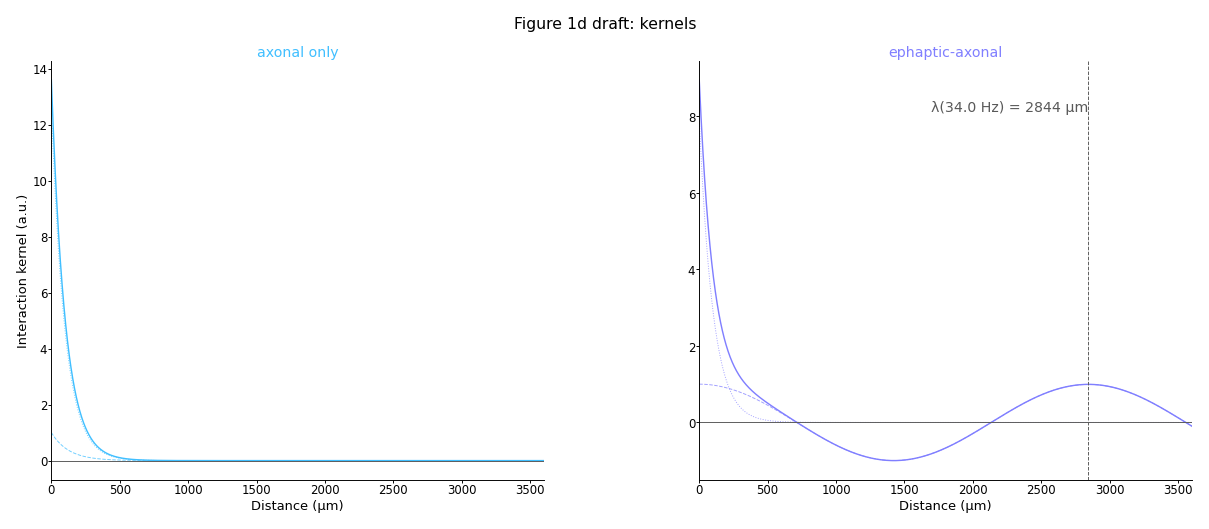

In [7]:
fig = plt.figure(figsize=(7.0, 3.0), constrained_layout=True)
axes = two_panel_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])
draw_kernel_comparison(kernels, axes)
_ = fig.suptitle("Figure 1d draft: kernels")


## Draft panel a schematic

First compose the network-differentiation schematic as a standalone editable Matplotlib panel before deciding whether to place it into the full Figure 1 layout.

{'axes': <Axes: >}

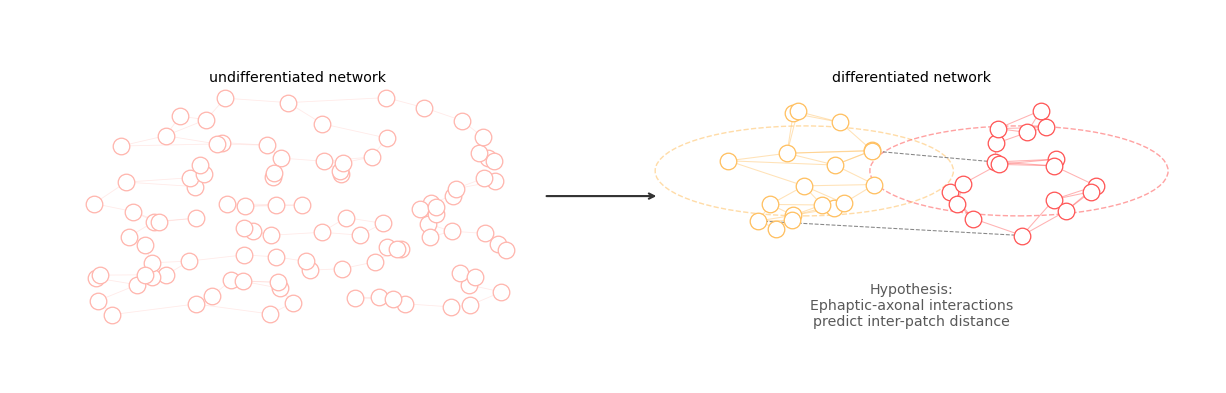

In [8]:
# Standalone draft for panel a before integration into the composed figure.
fig, ax = plt.subplots(figsize=(7.1, 2.2), constrained_layout=True)
draw_network_differentiation_schematic(None, ax)


## Compose Figure 1 draft

The 12-column layout is intentionally conservative. Panel `a` is editable placeholder content; panels `b-e` are simulation-derived.

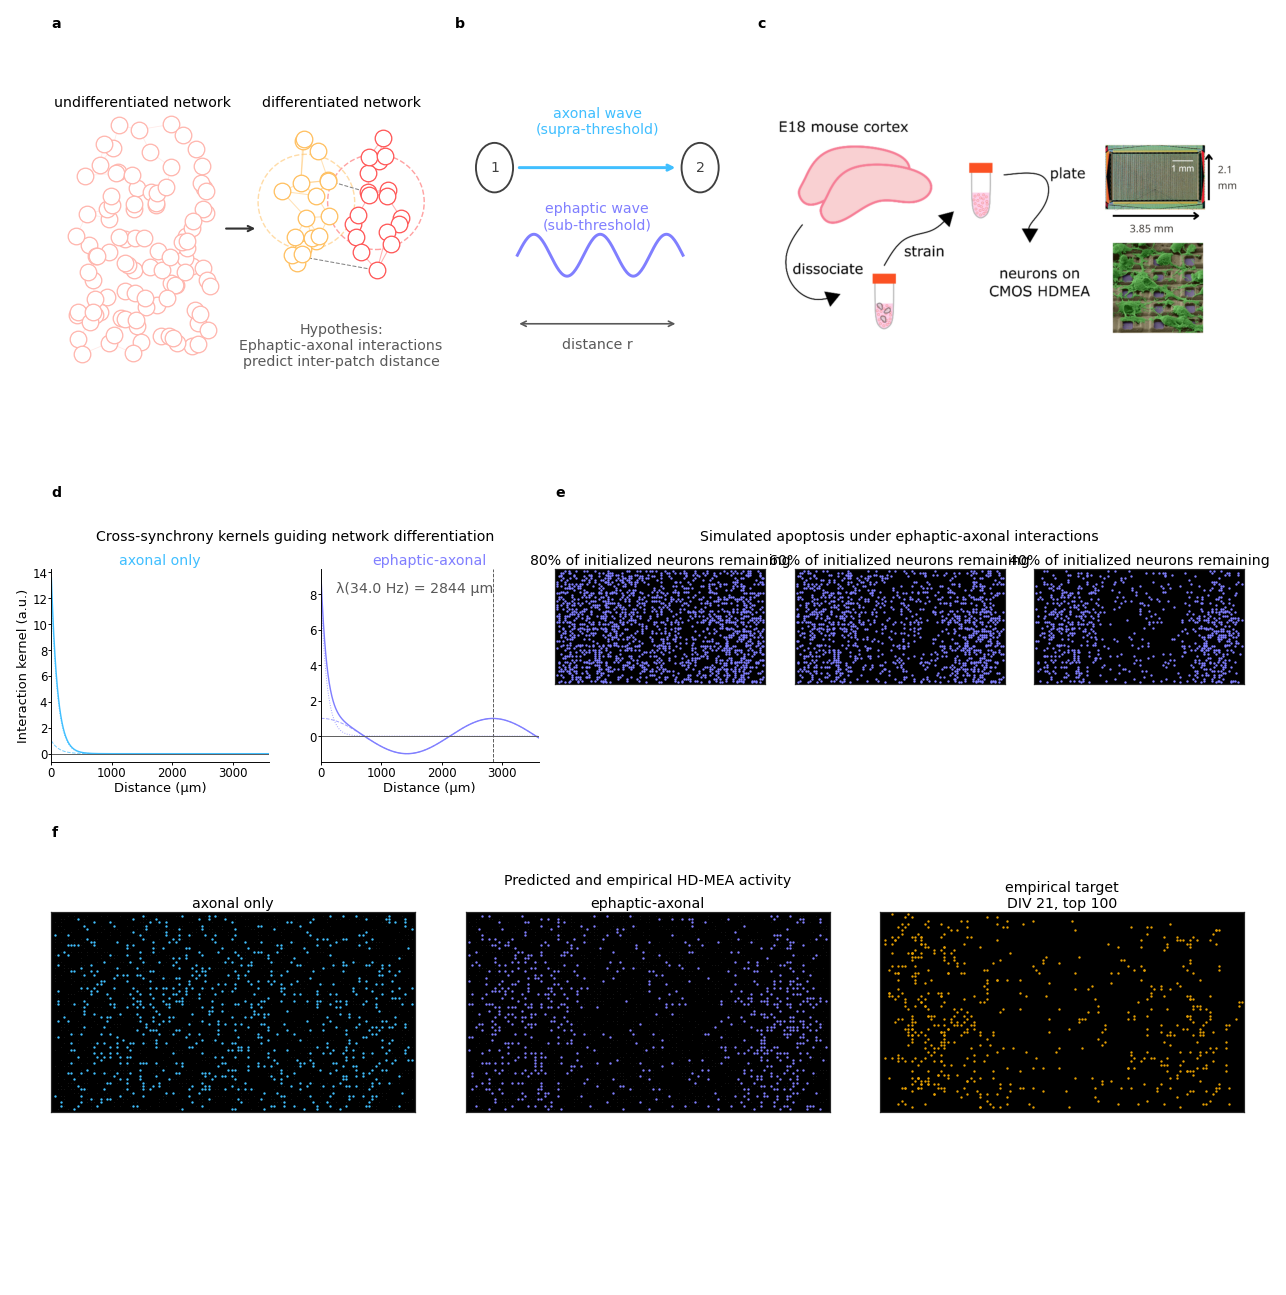

In [9]:
figure1_data = {
    "grid": grid,
    "kernels": kernels,
    "history_df": history_df,
    "simulation_results": simulation_results,
    "milestones": milestones,
    "empirical_figure5_target": empirical_figure5_target,
}

composed = compose_figure(
    figure(width="two_column", height_mm=190.0, rows=[0.62, 0.42, 0.70], row_gaps=[0.0, 0.0], constrained_layout=False),
    [
        panel(
            "schematic",
            label="a",
            loc=(0, 0, 1, 4),
            draw=draw_network_differentiation_schematic,
            data=None,
            options={"show_placeholder": SHOW_PLACEHOLDERS},
        ),
        panel(
            "kernel_origin",
            label="b",
            loc=(0, 4, 1, 3),
            draw=draw_kernel_origin_schematic,
            data=kernels,
        ),
        panel(
            "plating_methods",
            label="c",
            loc=(0, 7, 1, 5),
            draw=draw_plating_methods_image,
            data=PLATING_METHODS_IMAGE_PATH,
        ),
        panel(
            "kernels",
            label="d",
            suptitle="Cross-synchrony kernels guiding network differentiation",
            loc=(1, 0, 1, 5),
            draw=draw_kernel_comparison,
            data=kernels,
            axes_factory=two_panel_axes_factory,
        ),
        panel(
            "milestones",
            label="e",
            suptitle="Simulated apoptosis under ephaptic-axonal interactions",
            loc=(1, 5, 1, 7),
            draw=draw_milestone_strip,
            data=figure1_data,
            axes_factory=three_panel_axes_factory,
        ),
        panel(
            "outcomes",
            label="f",
            suptitle="Predicted and empirical HD-MEA activity",
            loc=(2, 0, 1, 12),
            draw=draw_model_outcome_maps,
            data=figure1_data,
            axes_factory=three_panel_axes_factory,
        ),

    ],
)
composed.fig.subplots_adjust(left=0.005, right=0.995, top=0.99, bottom=0.015)


## Paper Reporting CSVs

Writes one methods CSV and one results CSV for paper reporting. The tables are derived from cached Figure 1 simulation outputs and do not rerun simulations.

In [10]:

# Figure 1 paper-facing reporting tables. These are derived from cached simulation outputs only.
REPORT_TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _method_row(parameter, value, meaning, units=""):
    return {
        "figure": "figure_1",
        "parameter": str(parameter),
        "value": str(value),
        "units": str(units),
        "meaning": str(meaning),
    }


def _result_row(section, statistic, value, *, entity="", units="", ci_low=np.nan, ci_high=np.nan, n=np.nan, note=""):
    return {
        "figure": "figure_1",
        "section": str(section),
        "entity": str(entity),
        "statistic": str(statistic),
        "value": value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "units": str(units),
        "n": n,
        "note": str(note),
    }


method_rows = [
    _method_row("cache_version", CACHE_VERSION, "Version key for Figure 1 simulation/cache compatibility."),
    _method_row("random_seed", sim_config.random_seed, "Random seed for differentiation simulation."),
    _method_row("grid_columns", sim_config.grid_columns, "Number of simulated lattice columns."),
    _method_row("grid_rows", sim_config.grid_rows, "Number of simulated lattice rows."),
    _method_row("pitch_um", sim_config.pitch_um, "Spatial pitch of simulated lattice nodes.", "um"),
    _method_row("hz", sim_config.hz, "Oscillation frequency used for ephaptic correlation kernel.", "Hz"),
    _method_row("v_eph_m_s", sim_config.v_eph_m_s, "Ephaptic propagation speed used by the Figure 1 simulation.", "m/s"),
    _method_row("v_ax_m_s", sim_config.v_ax_m_s, "Axonal propagation speed used by the Figure 1 simulation.", "m/s"),
    _method_row("lambda_eph_um", sim_config.lambda_eph_um, "Ephaptic spatial length scale used by the kernel.", "um"),
    _method_row("axonal_decay_um", sim_config.axonal_decay_um, "Axonal-only exponential decay length scale.", "um"),
    _method_row("subsample_size", sim_config.subsample_size, "Number of neighbors sampled per simulation update."),
    _method_row("plating_loss_fraction", sim_config.plating_loss_fraction, "Initial random plating loss fraction before model-based selection."),
    _method_row("target_fraction", sim_config.target_fraction, "Target retained fraction after model-based differentiation."),
    _method_row("milestone_step_fraction", sim_config.milestone_step_fraction, "Fractional decrement between stored simulation milestones."),
    _method_row("empirical_target_div", resolved_empirical_target_div, "DIV used for Figure 5 empirical active-electrode target."),
    _method_row("empirical_target_wells", FIGURE5_AGGREGATE_WELLS, "Wells included in Figure 5 empirical active-electrode target."),
    _method_row("empirical_top_n", FIGURE5_EMPIRICAL_TOP_N, "Top active electrodes per recording used for Figure 5 empirical active-electrode target."),
]

result_rows = [
    _result_row("simulation_counts", "initial_count", params.get("initial_count", np.nan), units="nodes"),
    _result_row("simulation_counts", "plated_count", params.get("plated_count", np.nan), units="nodes"),
    _result_row("simulation_counts", "target_count", params.get("target_count", np.nan), units="nodes"),
    _result_row("simulation_counts", "simulated_area", sim_config.grid_columns * sim_config.pitch_um * sim_config.grid_rows * sim_config.pitch_um / 1_000_000.0, units="mm^2"),
]

if isinstance(history_df, pd.DataFrame) and not history_df.empty:
    id_candidates = [c for c in ["model_key", "model", "model_label", "milestone", "fraction", "step"] if c in history_df.columns]
    metric_candidates = [c for c in history_df.columns if c not in id_candidates]
    for _, row in history_df.iterrows():
        entity = "; ".join(f"{c}={row[c]}" for c in id_candidates)
        for col in metric_candidates:
            value = row[col]
            if np.isscalar(value) and not isinstance(value, (list, tuple, dict, np.ndarray)):
                result_rows.append(_result_row("simulation_history", col, value, entity=entity))

if isinstance(kernels, dict):
    kernel_value_by_model = {
        "axonal_only": "axonal",
        "ephaptic_axonal": "ephaptic_axonal",
    }
    for model_key, value_key in kernel_value_by_model.items():
        kernel = kernels.get(model_key, {})
        if isinstance(kernel, dict):
            distance = np.asarray(kernel.get("r_um", []), dtype=float)
            value = np.asarray(kernel.get(value_key, []), dtype=float)
            if distance.size and value.size and distance.size == value.size:
                ok = np.isfinite(distance) & np.isfinite(value)
                if np.any(ok):
                    d = distance[ok]
                    v = value[ok]
                    result_rows.extend([
                        _result_row("distance_kernels", "peak_distance_um", float(d[np.nanargmax(v)]), entity=model_key, units="um"),
                        _result_row("distance_kernels", "peak_value", float(np.nanmax(v)), entity=model_key),
                        _result_row("distance_kernels", "minimum_value", float(np.nanmin(v)), entity=model_key),
                    ])

if isinstance(empirical_figure5_target, pd.DataFrame) and not empirical_figure5_target.empty:
    result_rows.extend([
        _result_row("empirical_figure5_target", "n_selected_electrode_rows", int(len(empirical_figure5_target)), units="electrode rows"),
        _result_row("empirical_figure5_target", "n_recordings", int(empirical_figure5_target["recording_id"].nunique()), units="recordings"),
        _result_row("empirical_figure5_target", "n_unique_electrodes", int(empirical_figure5_target["electrode"].nunique()), units="electrodes"),
        _result_row("empirical_figure5_target", "x_extent_um", float(empirical_figure5_target["x_um"].max() - empirical_figure5_target["x_um"].min()), units="um"),
        _result_row("empirical_figure5_target", "y_extent_um", float(empirical_figure5_target["y_um"].max() - empirical_figure5_target["y_um"].min()), units="um"),
    ])

figure1_methods_df = pd.DataFrame(method_rows)
figure1_results_df = pd.DataFrame(result_rows)
figure1_methods_df.to_csv(REPORT_TABLE_DIR / "figure1_methods.csv", index=False)
figure1_results_df.to_csv(REPORT_TABLE_DIR / "figure1_results.csv", index=False)
print(f"Saved Figure 1 paper reporting CSVs to {REPORT_TABLE_DIR}")
display(figure1_methods_df)
display(figure1_results_df.head(20))


Saved Figure 1 paper reporting CSVs to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/tables


,figure,parameter,value,units,meaning
0,figure_1,cache_version,figure5_aligned_differentiation_v1,,Version key for Figure 1 simulation/cache comp...
1,figure_1,random_seed,0,,Random seed for differentiation simulation.
2,figure_1,grid_columns,110,,Number of simulated lattice columns.
3,figure_1,grid_rows,60,,Number of simulated lattice rows.
4,figure_1,pitch_um,35.0,um,Spatial pitch of simulated lattice nodes.
5,figure_1,hz,45.0,Hz,Oscillation frequency used for ephaptic correl...
6,figure_1,v_eph_m_s,0.0833,m/s,Ephaptic propagation speed used by the Figure ...
7,figure_1,v_ax_m_s,0.6,m/s,Axonal propagation speed used by the Figure 1 ...
8,figure_1,lambda_eph_um,1000000.0,um,Ephaptic spatial length scale used by the kernel.
9,figure_1,axonal_decay_um,100.0,um,Axonal-only exponential decay length scale.


,figure,section,entity,statistic,value,ci_low,ci_high,units,n,note
0,figure_1,simulation_counts,,initial_count,6600.000000,NaN,NaN,nodes,NaN,
1,figure_1,simulation_counts,,plated_count,1980.000000,NaN,NaN,nodes,NaN,
2,figure_1,simulation_counts,,target_count,792.000000,NaN,NaN,nodes,NaN,
3,figure_1,simulation_counts,,simulated_area,8.085000,NaN,NaN,mm^2,NaN,
4,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,round,1.000000,NaN,NaN,,NaN,
5,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,plating_loss_fraction,0.700000,NaN,NaN,,NaN,
6,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,plated_starting_count,1980.000000,NaN,NaN,,NaN,
7,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,active_before,1980.000000,NaN,NaN,,NaN,
8,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,active_after,1970.000000,NaN,NaN,,NaN,
9,figure_1,simulation_history,model=axonal_only; model_label=Axonal only,sampled,20.000000,NaN,NaN,,NaN,


## Export

PDF and SVG preserve editable vector content where Matplotlib supports it. Dense node maps are rasterized within the vector containers to keep files manageable.

In [11]:
if SAVE_FIGURE:
    saved_paths = export_figure(composed.fig, OUTPUT_DIR / "figure1_differentiation_draft")
    print("Saved:")
    for path in saved_paths:
        print(f"- {path}")

Saved:
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.pdf
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.svg
- /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure1_differentiation/figure1_differentiation_draft.png


## Promotion notes

Keep editing layout and panel choices here. Once the figure content stabilizes, the reusable pieces worth promoting are likely the kernel comparison and HD-MEA node-map rendering.